# 🤖 04 - Gözetimli Makine Öğrenmesi (Segment-Level Classification)
## Uydu Telemetri Anomali Tespiti

**Amaç:** Segment bazlı özellik matrisini kullanarak gözetimli anomali tespiti modellerini eğitmek.

### Modeller:
1. Random Forest (Ensemble)
2. Support Vector Machine (SVM)
3. XGBoost (Gradient Boosting)
4. MLP (Deep Learning)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

import sys
sys.path.insert(0, '..')
from src.models.supervised import SupervisedAnomalyDetector

print('✅ Kütüphaneler ve Model Sınıfı Yüklendi.')


✅ Kütüphaneler ve Model Sınıfı Yüklendi.


---
## 📥 Bölüm 1: Veri Hazırlama


In [2]:
df_features = pd.read_parquet('../data/features/segment_features.parquet')
print(f"📊 Özellik Matrisi Yüklendi: {df_features.shape}")

drop_cols = ['segment', 'anomaly', 'train', 'channel']
feature_cols = [c for c in df_features.columns if c not in drop_cols]

X = df_features[feature_cols].fillna(0)
y = df_features['anomaly']

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.15, random_state=42, stratify=y_trainval)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

print("\nSMOTE Öncesi Eğitim Sınıf Dağılımı:")
print(y_train.value_counts())
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("\nSMOTE Sonrası Eğitim Sınıf Dağılımı:")
print(y_train_sm.value_counts())

scaler = RobustScaler()
X_train_s = scaler.fit_transform(X_train_sm)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print("\n✅ Veri Bölme, Dengeleme ve Ölçeklendirme Tamamlandı!")


📊 Özellik Matrisi Yüklendi: (2123, 28)
Train: (1443, 24), Val: (255, 24), Test: (425, 24)

SMOTE Öncesi Eğitim Sınıf Dağılımı:
anomaly
0    1148
1     295
Name: count, dtype: int64

SMOTE Sonrası Eğitim Sınıf Dağılımı:
anomaly
0    1148
1    1148
Name: count, dtype: int64

✅ Veri Bölme, Dengeleme ve Ölçeklendirme Tamamlandı!


---
## 🌲 Bölüm 2: Random Forest ve XGBoost


In [3]:
detector = SupervisedAnomalyDetector(random_state=42)

rf_model = detector.train_random_forest(X_train_s, y_train_sm, tune=False)
xgb_model = detector.train_xgboost(X_train_s, y_train_sm, X_val_s, y_val)


🌲 Random Forest eğitiliyor...
🚀 XGBoost eğitiliyor...


---
## ⚔️ Bölüm 3: SVM


In [4]:
svm_model = detector.train_svm(X_train_s, y_train_sm, kernel='rbf')


⚔️ SVM (rbf kernel) eğitiliyor...


---
## 🧠 Bölüm 4: MLP (Derin Öğrenme)


🧠 MLP eğitiliyor...
Epoch 1/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8515 - loss: 0.3557 - val_accuracy: 0.9216 - val_loss: 0.3367
Epoch 2/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9338 - loss: 0.1777 - val_accuracy: 0.9373 - val_loss: 0.2153
Epoch 3/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9473 - loss: 0.1532 - val_accuracy: 0.9373 - val_loss: 0.1525
Epoch 4/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9512 - loss: 0.1383 - val_accuracy: 0.9451 - val_loss: 0.1366
Epoch 5/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9499 - loss: 0.1353 - val_accuracy: 0.9529 - val_loss: 0.1169
Epoch 6/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9630 - loss: 0.1017 - val_accuracy: 0.9490 - val_loss: 0.1186
Epoch 7/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9604 - loss: 0.1057 - val_accuracy: 0.9373 - val_loss: 0.1092
Epoch 8/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9639 - loss: 0.1009 - val_accuracy

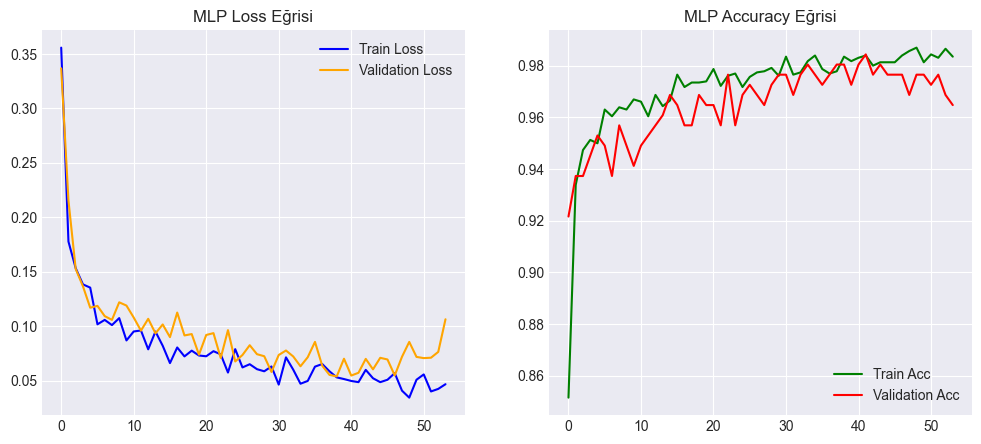

In [5]:
mlp_model, history = detector.train_mlp(
    X_train_s, y_train_sm.values,
    X_val_s, y_val.values,
    epochs=80, batch_size=32
)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('MLP Loss Eğrisi'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Acc', color='red')
plt.title('MLP Accuracy Eğrisi'); plt.legend()
plt.show()


---
## 📊 Bölüm 5: Model Değerlendirme


In [6]:
print("=== Modeller Değerlendiriliyor ===")
detector.evaluate_model('RandomForest', X_test_s, y_test)
detector.evaluate_model('XGBoost', X_test_s, y_test)
detector.evaluate_model('SVM', X_test_s, y_test)
detector.evaluate_model('MLP', X_test_s, y_test.values)

results_df = pd.DataFrame(detector.metrics).T
display(results_df.style.background_gradient(cmap='Blues'))


=== Modeller Değerlendiriliyor ===
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


,Accuracy,Precision,Recall,F1_Score,AUC,FAR
RandomForest,0.938824,0.867470,0.827586,0.847059,0.983881,0.032544
XGBoost,0.948235,0.901235,0.839080,0.869048,0.986499,0.023669
SVM,0.891765,0.715789,0.781609,0.747253,0.898796,0.079882
MLP,0.967059,0.929412,0.908046,0.918605,0.991872,0.017751


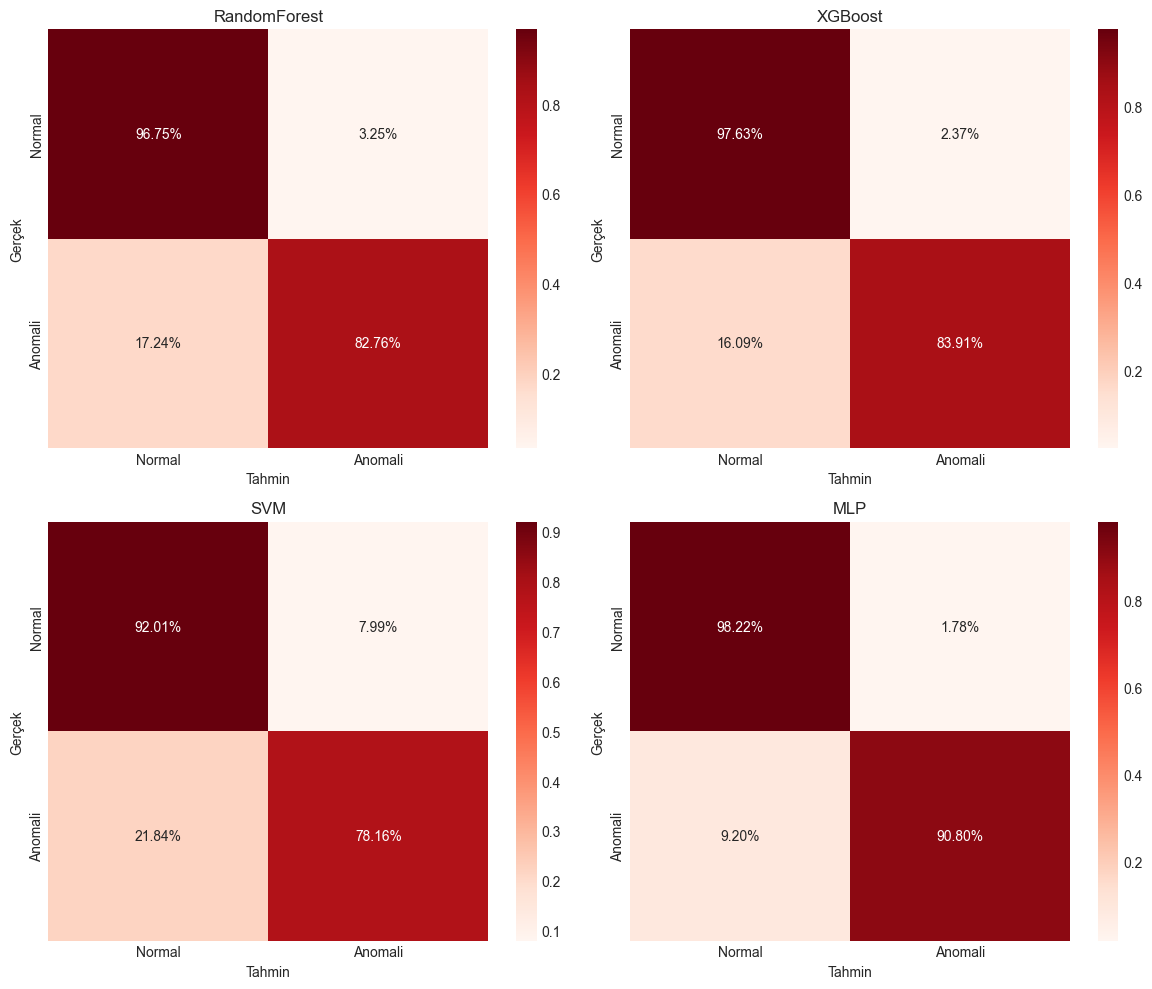

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, model_name in enumerate(detector.models.keys()):
    model = detector.models[model_name]
    if model_name == 'MLP':
        y_pred = (model.predict(X_test_s, verbose=0) >= 0.5).astype(int).flatten()
    else:
        y_pred = model.predict(X_test_s)

    cm = confusion_matrix(y_test, y_pred, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Reds', ax=axes[i],
                xticklabels=['Normal', 'Anomali'], yticklabels=['Normal', 'Anomali'])
    axes[i].set_title(f'{model_name}')
    axes[i].set_xlabel('Tahmin'); axes[i].set_ylabel('Gerçek')

plt.tight_layout()
plt.show()


---
## 🔍 Bölüm 6: ROC Eğrisi


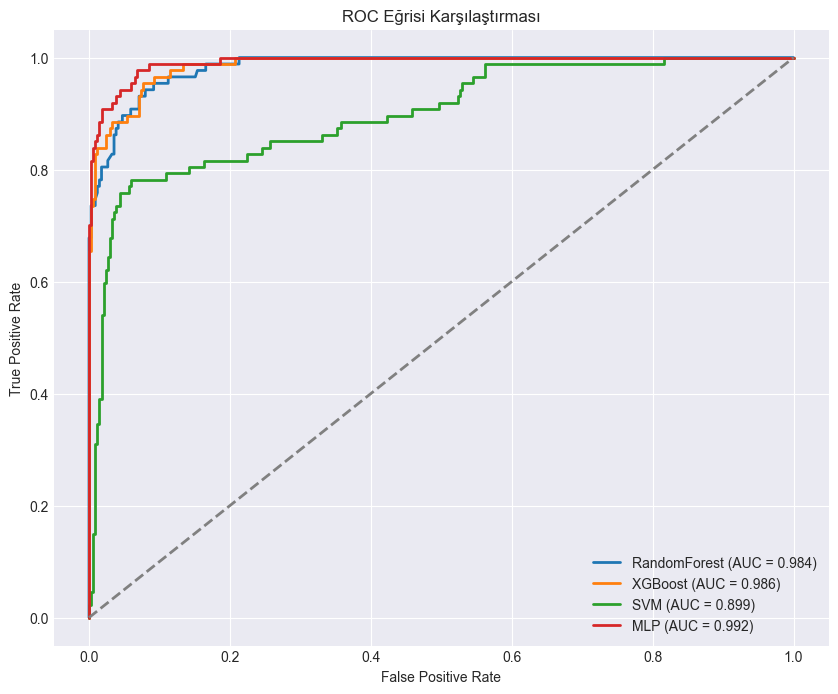

In [8]:
plt.figure(figsize=(10, 8))
for model_name, model in detector.models.items():
    if model_name == 'MLP':
        y_prob = model.predict(X_test_s, verbose=0).flatten()
    elif hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_s)[:, 1]
    else:
        y_prob = model.decision_function(X_test_s)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Eğrisi Karşılaştırması')
plt.legend(loc="lower right")
plt.show()


---
## 💾 Bölüm 7: Kaydetme


In [9]:
detector.save_model('RandomForest', '../models/rf_model.joblib')
detector.save_model('XGBoost', '../models/xgb_model.joblib')
detector.save_model('SVM', '../models/svm_model.joblib')
detector.save_model('MLP', '../models/mlp_model.keras')
detector.save_metadata('../reports/metrics/supervised_metrics.json')
print("✅ Tüm modeller kaydedildi.")


✅ Model kaydedildi: ../models/rf_model.joblib
✅ Model kaydedildi: ../models/xgb_model.joblib
✅ Model kaydedildi: ../models/svm_model.joblib
✅ Model kaydedildi: ../models/mlp_model.keras
📝 Metadata kaydedildi: ../reports/metrics/supervised_metrics.json
✅ Tüm modeller kaydedildi.


### HTML Rapor


In [10]:
%pip install jupyter nbconvert -q
!jupyter nbconvert --to html 04_model_supervised.ipynb --output ../reports/04_model_supervised_rapor.html


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\TAHA\AppData\Local\Programs\Python\Python313\Scripts\jupyter-nbconvert.EXE\__main__.py:4: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
[NbConvertApp] Converting notebook 04_model_supervised.ipynb to html
C:\Users\TAHA\AppData\Local\Programs\Python\Python313\Lib\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbfor